In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Download NLP resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Load CSV
df = pd.read_csv("Credit Default.csv")

# Preview
df.head()

,Income,Age,Loan,Loan to Income,Default
0,66155.92510,59.017015,8106.532131,0.122537,0
1,34415.15397,48.117153,6564.745018,0.190752,0
2,57317.17006,63.108049,8020.953296,0.139940,0
3,42709.53420,45.751972,6103.642260,0.142911,0
4,66952.68885,18.584336,8770.099235,0.130990,1


In [3]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Income          2000 non-null   float64
 1   Age             2000 non-null   float64
 2   Loan            2000 non-null   float64
 3   Loan to Income  2000 non-null   float64
 4   Default         2000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 78.3 KB


Income            0
Age               0
Loan              0
Loan to Income    0
Default           0
dtype: int64

In [5]:
df = df.fillna(0)

In [6]:
df = df.bfill()

In [8]:
if 'Customer_Notes' in df.columns:
    df['clean_text'] = df['Customer_Notes'].apply(clean_text)
else:
    print("Column not found. Available columns:", df.columns)

Column not found. Available columns: Index(['Income', 'Age', 'Loan', 'Loan to Income', 'Default'], dtype='str')


In [10]:
print(df.columns.tolist())

['Income', 'Age', 'Loan', 'Loan to Income', 'Default']


In [11]:
df.columns = df.columns.str.strip()

In [13]:
numerical_cols = [col for col in numerical_cols if col in df.columns]
num_df = df[numerical_cols]

In [14]:
numerical_cols = [
    'credit_score',
    'age',
    'balance',
    'estimated_salary'
]

In [15]:
df.columns = df.columns.str.strip()

In [16]:
scaler = StandardScaler()

scaled_num = scaler.fit_transform(num_df)
scaled_num_df = pd.DataFrame(scaled_num)

In [18]:
print(locals())

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', "# Data handling\nimport pandas as pd\nimport numpy as np\n\n# Visualization\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Preprocessing\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.cluster import KMeans\n\n# NLP\nimport nltk\nfrom nltk.corpus import stopwords\nfrom nltk.stem import WordNetLemmatizer\nimport re\n\n# Vectorization\nfrom sklearn.feature_extraction.text import TfidfVectorizer\n\n# Download NLP resources (run once)\nnltk.download('stopwords')\nnltk.download('wordnet')", '# Load CSV\ndf = pd.read_csv("Credit Default.csv")\n\n# Preview\ndf.head()', 'df.info()\ndf.describe()\n\n# Check missing values\ndf.isnull().sum()', "# Drop duplicates\ndf = df.drop_duplicates()\n\n# Fill m

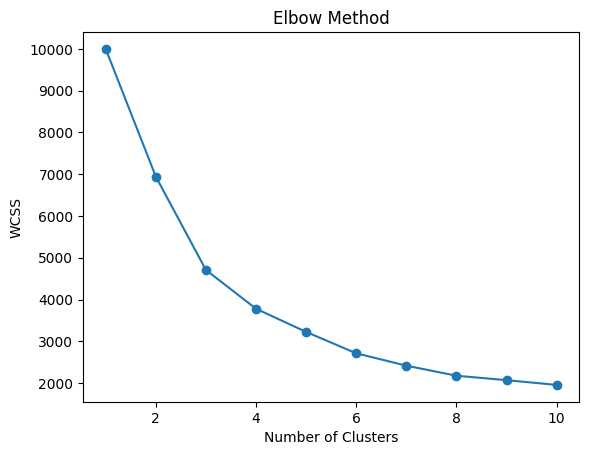

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
final_df = scaler.fit_transform(df)

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(final_df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(final_df)

In [26]:
df.columns = df.columns.str.strip()

In [27]:
df.groupby('Cluster').mean()

,Income,Age,Loan,Loan to Income,Default
Cluster,,,,,
0,45412.188607,26.401412,7272.856747,0.159879,1.0
1,48960.411546,48.632590,6631.201120,0.139145,0.0
2,42630.982432,39.402357,2020.622787,0.050732,0.0
